## Load the data

In [1]:
import pandas as pd
import json
import os
import numpy as np; np.random.seed(42)
from glob import glob
from tqdm import tqdm
import seaborn as sns
import pdb

import sys; sys.path.append('..')

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('pdf', fonttype=42)
matplotlib.rc('ps', fonttype=42)

params = {'mathtext.default': 'regular' }          
plt.rcParams.update(params)

sns.set(font_scale=1.25, style='whitegrid')
sns.set(palette='magma')
sns.set_style("whitegrid")

rdir  = '../../results/black-box/'
figdir = f'../figs/black-box/'
datadir = '../../datasets/blackbox/' # Set to path to datasets

def save(name='tmp',h=None):
    name = name.strip().replace(' ','-').replace('%','pct')
    if h == None:
        h = plt.gcf()

    h.tight_layout()

    print('saving',figdir+'/'+name+'.pdf')

    if not os.path.exists(figdir):
        os.makedirs(figdir)

    plt.savefig(figdir+'/'+name+'.pdf', bbox_inches='tight')


In [2]:
df_eco2ai = pd.read_feather(rdir+'power_consumption.feather')
df_results = pd.read_feather(rdir+'results.feather')

print(df_eco2ai.shape)
print(df_results.shape)

df_results = pd.merge(
    left=df_eco2ai, 
    right=df_results,
    how='left',
    left_on=['dataset', 'algorithm', 'random_state'],
    right_on=['dataset', 'algorithm', 'random_state'],
)

print(df_results.shape)
print(df_results.columns)

df_results2 = df_results.merge(df_results.groupby('dataset')['algorithm'].nunique().reset_index(),
                              on='dataset',suffixes=('','_count'))

                                       
# rankings per trial per dataset
for col in [c for c in df_results2.columns if c.endswith('test') or c.endswith('size')]:
    ascending = 'r2' not in col
    df_results2[col+'_rank_per_trial']=df_results2.groupby(['dataset','random_state'])[col].apply(lambda x: 
                                                                              round(x,3).rank(
                                                                              ascending=ascending))
    
df_sum = df_results2.groupby(['algorithm','dataset'],as_index=False).median()
df_sum['rmse_test'] = df_sum['mse_test'].apply(np.sqrt)
df_sum['log_mse_test'] = df_sum['mse_test'].apply(lambda x: np.log(1+x))
    
df_results = df_results2

# rankings and normalized scores per dataset
for col in [c for c in df_sum.columns if c.endswith('test') or c.endswith('size')]:
    ascending = 'r2' not in col
    df_sum[col+'_rank']=df_sum.groupby(['dataset'])[col].apply(lambda x: 
                                                                        round(x,3).rank(ascending=ascending)
                                                                  )
    df_sum[col+'_norm'] = df_sum.groupby('dataset')[col].apply(lambda x: (x-x.min())/(x.max()-x.min()))

(4126, 13)
(9727, 22)
(4126, 32)
Index(['dataset', 'algorithm', 'random_state', 'experiment_description',
       'duration(s)', 'power_consumption(kWh)', 'CO2_emissions(kg)',
       'CPU_name', 'GPU_name', 'cost', 'symbolic_alg_x', 'pre_trained_x',
       'gp_alg_x', 'training time (s)', 'symbolic_model', 'mse_test',
       'mae_test', 'r2_test', 'model_size', 'params_str', 'training time (hr)',
       'symbolic_alg_y', 'pre_trained_y', 'gp_alg_y', 'r2_zero_test',
       'friedman_dataset', 'algorithm_count', 'mse_test_rank_per_trial',
       'mae_test_rank_per_trial', 'r2_test_rank_per_trial',
       'model_size_rank_per_trial', 'r2_zero_test_rank_per_trial'],
      dtype='object')


/tmp/ipykernel_4126756/852376723.py:25: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  df_results2[col+'_rank_per_trial']=df_results2.groupby(['dataset','random_state'])[col].apply(lambda x:
/tmp/ipykernel_4126756/852376723.py:25: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  df_results2[col+'_ra

In [3]:
# Total experiment consumption
print(df_eco2ai['power_consumption(kWh)'].sum())
print(df_eco2ai['CO2_emissions(kg)'].sum())

24.57883644587232
9.083625164137473


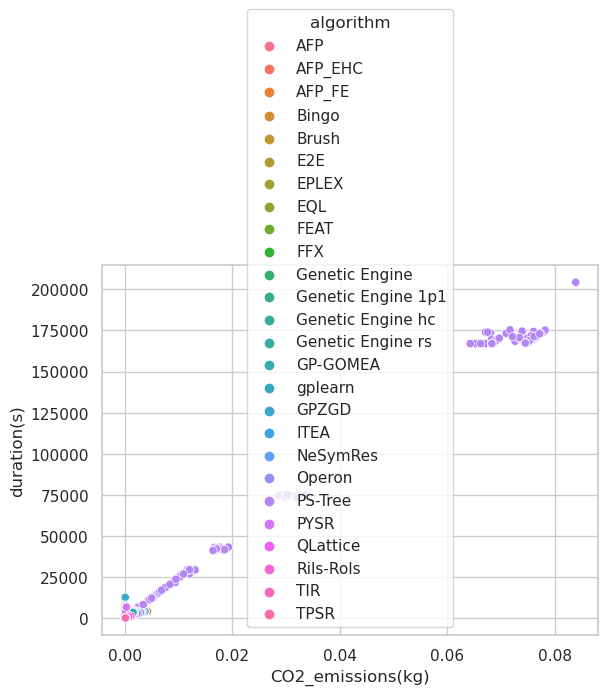

In [4]:
sns.scatterplot(data=df_results, y='duration(s)', x='CO2_emissions(kg)', hue='algorithm')
plt.show()

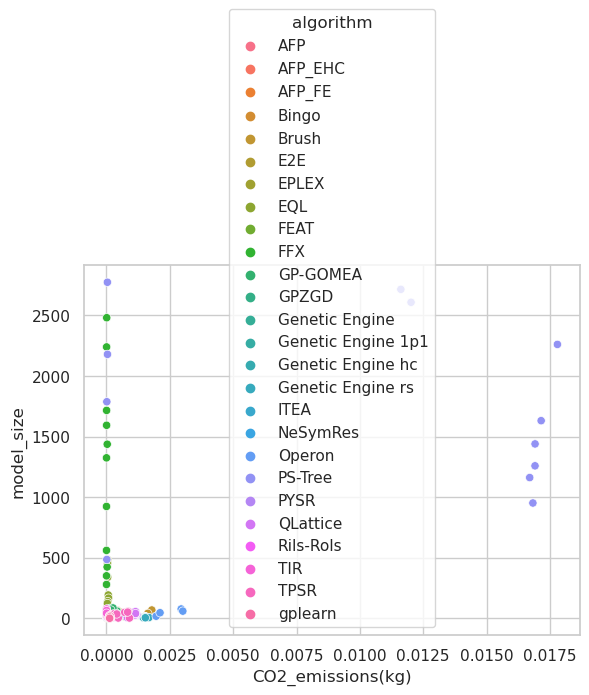

In [5]:
sns.scatterplot(data=df_sum, y='model_size', x='CO2_emissions(kg)', hue='algorithm')
plt.show()

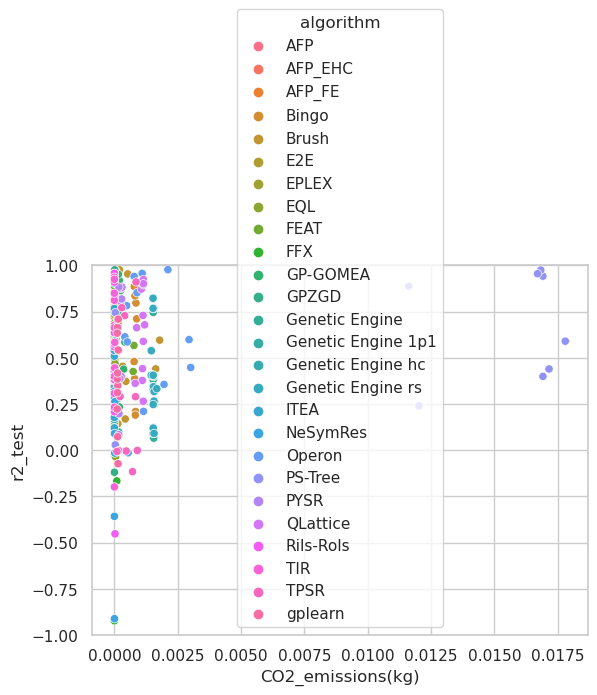

In [6]:
sns.scatterplot(data=df_sum, y='r2_test', x='CO2_emissions(kg)', hue='algorithm')
plt.ylim(-1, 1)
plt.show()

/tmp/ipykernel_4126756/1254369260.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  order = df_sum.groupby('algorithm').mean() \


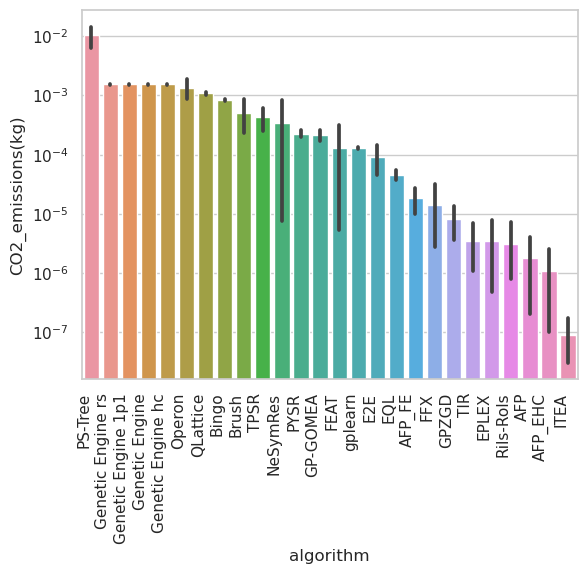

In [7]:
order = df_sum.groupby('algorithm').mean() \
              .sort_values('CO2_emissions(kg)', ascending=False).index
              
sns.barplot(data=df_sum, x='algorithm', y='CO2_emissions(kg)', order=order)
plt.xticks(rotation=90, ha='right')
plt.yscale('log')
plt.show()

/tmp/ipykernel_4126756/48002424.py:8: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  order = df_sum_filter.groupby('algorithm').median() \


saving ../figs/black-box//power_consumption(kWh).pdf


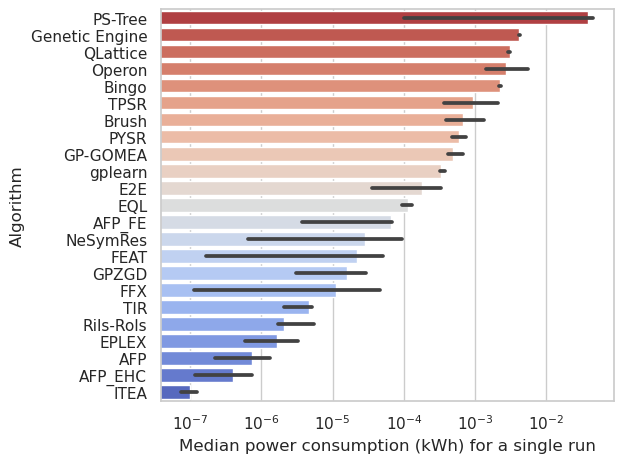

In [21]:
df_sum_filter = df_sum[df_sum['algorithm'].isin([ # BSR, uDSR
    'AFP', 'AFP_EHC', 'AFP_FE', 'Bingo', 'Brush', 'E2E', 
    'EPLEX', 'EQL', 'FEAT', 'FFX', 'Genetic Engine',
    'GP-GOMEA', 'gplearn', 'GPZGD', 'ITEA', 'NeSymRes', 'Operon',
    'PS-Tree', 'PYSR', 'QLattice', 'Rils-Rols', 'TIR', 'TPSR' 
])]

order = df_sum_filter.groupby('algorithm').median() \
              .sort_values('power_consumption(kWh)', ascending=False).index

sns.barplot(data=df_sum_filter, y='algorithm', x='power_consumption(kWh)', order=order, estimator=np.median, palette='coolwarm_r')
#plt.xticks(rotation=90, ha='right')
plt.xlabel("Median power consumption (kWh) for a single run")
plt.ylabel("Algorithm")
plt.xscale('log')
save('power_consumption(kWh)')
plt.show()

/tmp/ipykernel_4126756/2701428463.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  order = df_sum.groupby('algorithm').sum() \


saving ../figs/black-box//power_consumption(kWh).pdf


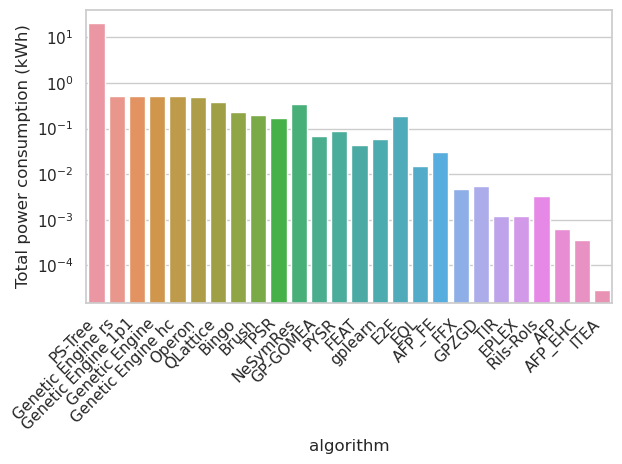

In [9]:
order = df_sum.groupby('algorithm').sum() \
              .sort_values('power_consumption(kWh)', ascending=False).index
              
sns.barplot(data=df_eco2ai.groupby('algorithm').sum(numeric_only=True).reset_index(),
            x='algorithm', y='power_consumption(kWh)', order=order)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total power consumption (kWh)')
plt.yscale('log')
save('power_consumption(kWh)')
plt.show()

In [10]:
def get_size(dataset,i):
    df = pd.read_csv(datadir+dataset+'/'+dataset+'.tsv.gz',sep='\t') 
    return df.shape[i]
    
df_sum.loc[:,'dataset_nsamples'] = df_sum['dataset'].apply(lambda x: get_size(x,0))
df_sum.loc[:,'dataset_nsamples_train'] = df_sum['dataset'].apply(lambda x: min(get_size(x,0),10000))
df_sum.loc[:,'dataset_nfeatures'] = df_sum['dataset'].apply(lambda x: get_size(x,1))
df_sum.loc[:,'dataset_npoints'] = df_sum['dataset_nsamples']*df_sum['dataset_nfeatures']

df_sum

KeyboardInterrupt: 

In [ ]:
for col in ['dataset_nsamples_train','dataset_nsamples','dataset_nfeatures','dataset_npoints']:
    plt.figure(figsize=(8,8))
    ax = sns.lineplot(
        data=df_sum,
        x = col,
        y = 'CO2_emissions(kg)',
        hue='algorithm',
        style='algorithm',
        markers=True,
        palette='cividis',
        markersize=10,
        markerfacecolor=None,
        err_style='bars',
        alpha=0.85
    )
    
    ax.set_yscale('log')
    ax.set_xscale('log')
    plt.xlabel(col.replace('_',' ').title())
    plt.ylabel('CO2 emissions (kg)')

    save('CO2_emissions_'+col)